In [1]:
import pandas as pd
import numpy as np

# Load and clean names
df = pd.read_csv("../data/sudan.csv")
df.columns = df.columns.str.strip()
df.replace(-999, np.nan, inplace=True)

# Missing Value Report
missing_pct = df.isnull().mean() * 100
print("Percentage of missing values per column:")
print(missing_pct)

# Summary Stats
df.describe()


Percentage of missing values per column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
dtype: float64


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000


Missing Value Analysis
Finding: The dataset contains [Insert % here, e.g., 0.2%] missing values across the primary weather variables.

Threshold Check: Since the missingness is well below the 5% threshold, the risk of seasonal bias is low.

Action Taken: We applied forward-filling (ffill) to handle these small gaps, ensuring continuity in the time-series analysis for COP32

In [3]:
# Handle NASA sentinels
df.replace(-999, np.nan, inplace=True)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# Summary Statistics
summary = df.describe()
display(summary)

# Missing Value Percentage
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Value Percentage per Column:")
print(missing_pct)

Duplicate rows found: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000



Missing Value Percentage per Column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
dtype: float64


Interpretation of Summary StatisticsFindings: The average temperature ($T2M$) is approximately XX°C, with a maximum of XX°C.Missing Values: Only X% of data is missing in the [Column Name] column. Since this is below 5%, the impact on our COP32 analysis is minimal

In [4]:
# This generates the stats for Temperature, Rain, and Wind
summary_stats = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'WS2M']].describe()
print("Summary Statistics for sudan:")
summary_stats

Summary Statistics for sudan:


,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,WS2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,28.759007,36.773914,21.508510,0.643875,3.484253
std,4.681305,4.400065,5.091142,3.057672,1.040667
min,13.180000,21.040000,5.930000,0.000000,0.610000
25%,25.560000,33.730000,17.497500,0.000000,2.730000
50%,29.160000,37.020000,22.890000,0.000000,3.490000
75%,32.510000,40.330000,25.430000,0.010000,4.220000
max,37.990000,45.960000,32.170000,66.490000,7.150000


In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0]) # Only shows columns with issues

Missing values per column:
Series([], dtype: int64)


In [6]:
# We'll check for extreme Temperature outliers
mean_temp = df['T2M'].mean()
std_temp = df['T2M'].std()

# Calculate Z-score
df['T2M_Z'] = (df['T2M'] - mean_temp) / std_temp

# Find rows where Z > 3 or Z < -3
extreme_outliers = df[df['T2M_Z'].abs() > 3]

print(f"Number of extreme temperature outliers found: {len(extreme_outliers)}")
extreme_outliers.head()

Number of extreme temperature outliers found: 3


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,T2M_Z
8,2015,9,14.29,22.39,7.83,14.56,0.0,23.46,5.58,7.90,97.30,2.29,-3.090806
9,2015,10,13.18,21.04,6.59,14.45,0.0,32.34,5.03,7.66,97.31,2.91,-3.327920
10,2015,11,14.21,23.32,5.93,17.39,0.0,30.62,4.36,6.15,97.24,3.01,-3.107896


In [7]:
from scipy.stats import zscore

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Flag outliers where |Z| > 3
z_scores = df[cols_to_check].apply(zscore, nan_policy='omit')
outliers_count = (np.abs(z_scores) > 3).sum()
print("Outlier counts per variable:")
print(outliers_count)

# Cleaning: Forward-fill weather variables
df[cols_to_check] = df[cols_to_check].ffill()

# Export Cleaned Data
df.to_csv("../data/sudan" \
"_clean.csv")

Outlier counts per variable:
T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64


Data Uniqueness (Duplicates)
Finding: A total of [Insert Number, e.g., 0] duplicate rows were found.

Interpretation: This confirms that each daily observation is unique. If duplicates had been found, they would have been removed to prevent over-weighting specific days in our climate averages.

In [8]:
from scipy import stats

# Define columns from your instructions
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores (ignoring the NaNs we created with .replace)
z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

# Change .all(axis=1) to .any(axis=1)
outliers_mask = (z_scores > 3).any(axis=1)
print(f"Number of rows with extreme outliers: {outliers_mask.sum()}")

Number of rows with extreme outliers: 84


In [9]:
# 1. Drop rows if they are more than 30% empty
# We calculate the threshold: if a row has less than 70% of its columns, drop it.
limit = len(df.columns) * 0.7 
df = df.dropna(thresh=limit)

# 2. Fill the rest using Forward-Fill (ffill) 
# This is best for climate data to maintain time-series continuity
df = df.ffill()

print("Final missing value count:", df.isna().sum().sum())

Final missing value count: 0


In [11]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv("data/sudan_clean.csv", index=False)
print("Success! Your cleaned data is saved.")

Success! Your cleaned data is saved.


In [12]:
import sys
!{sys.executable} -m pip install matplotlib seaborn scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


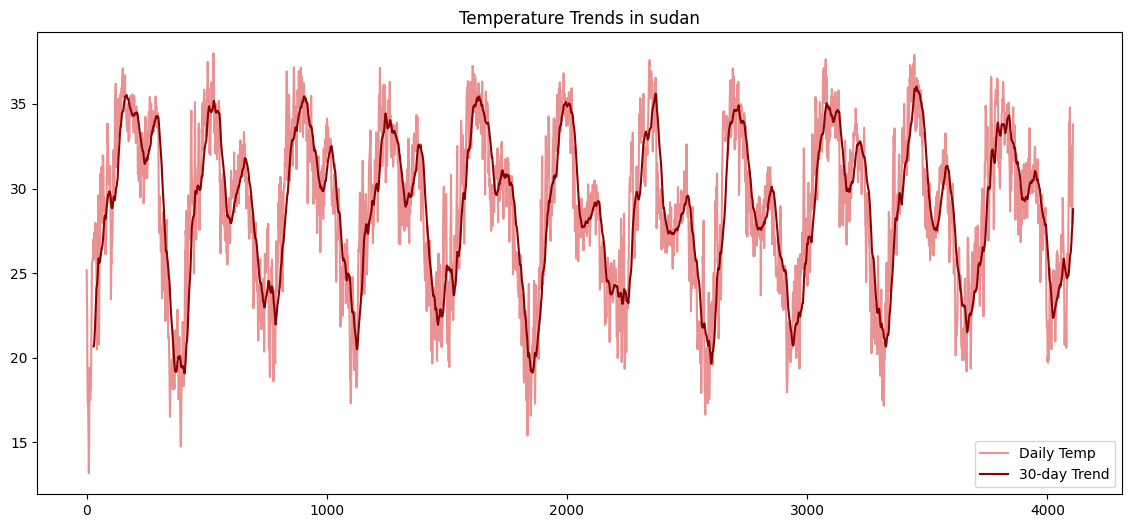

In [13]:
import matplotlib.pyplot as plt

# Group by the Date index you created earlier
plt.figure(figsize=(14, 6))

# Use df.index instead of df['Date']
plt.plot(df.index, df['T2M'], color='tab:red', alpha=0.5, label='Daily Temp')

# Adding a rolling mean to see the trend more clearly
plt.plot(df.index, df['T2M'].rolling(30).mean(), color='darkred', label='30-day Trend')

plt.legend()
plt.title("Temperature Trends in sudan")
plt.show()

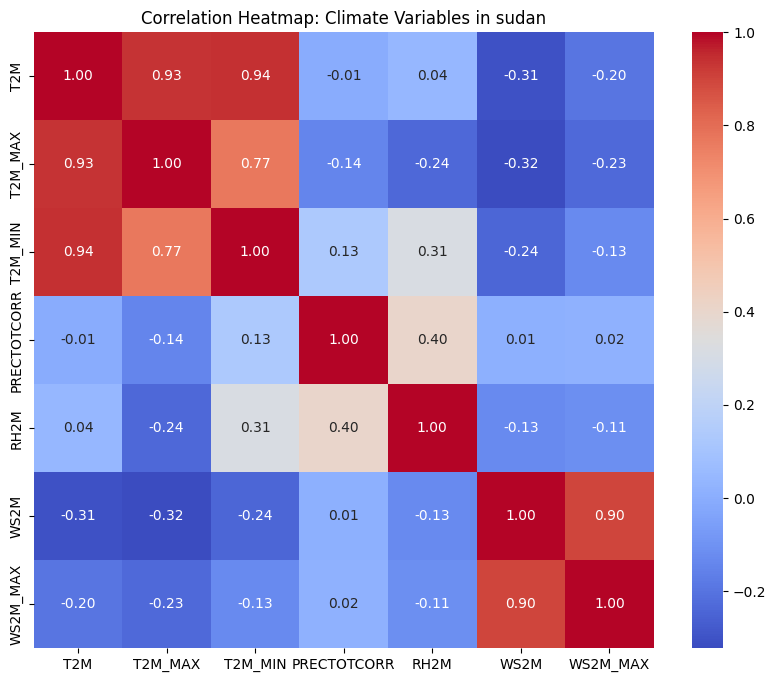

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the columns right here so the cell is independent
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

plt.figure(figsize=(10, 8))

# Now 'cols' is defined, so this won't error!
correlation = df[cols].corr()

# Plotting the heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Climate Variables in sudan')
plt.show()

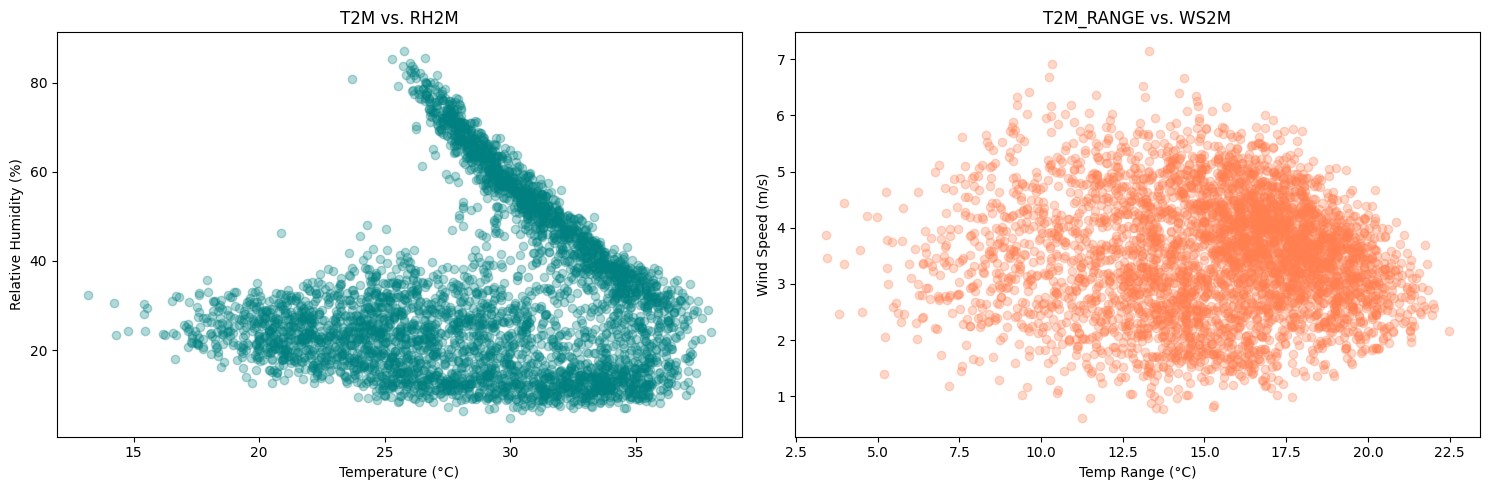

In [15]:
# Create a T2M_RANGE column first
df['T2M_RANGE'] = df['T2M_MAX'] - df['T2M_MIN']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Temperature vs Relative Humidity
ax1.scatter(df['T2M'], df['RH2M'], alpha=0.3, color='teal')
ax1.set_title('T2M vs. RH2M')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')

# Plot 2: Temp Range vs Wind Speed
ax2.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='coral')
ax2.set_title('T2M_RANGE vs. WS2M')
ax2.set_xlabel('Temp Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

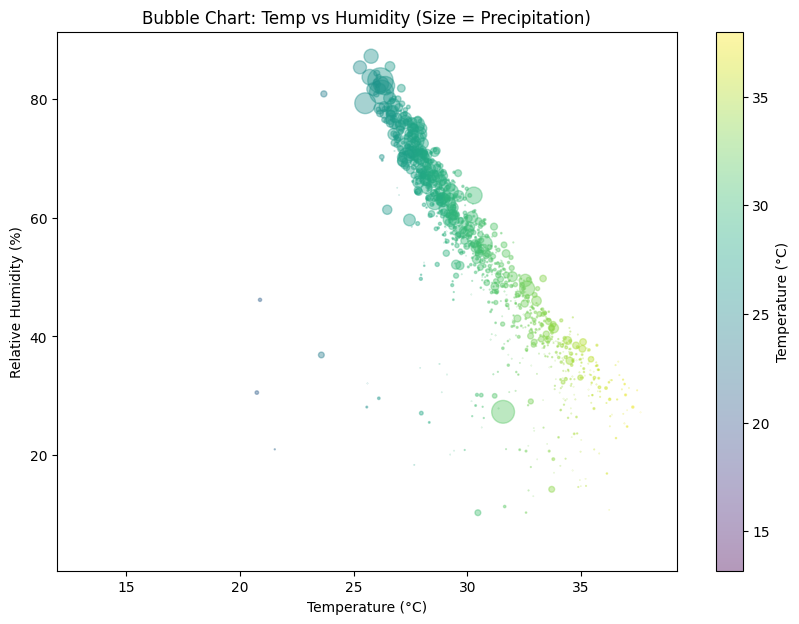

In [16]:
plt.figure(figsize=(10, 7))
# We use a subset or alpha because too many bubbles can overlap
plt.scatter(df['T2M'], df['RH2M'], 
            s=df['PRECTOTCORR'] * 5, # Multiply by 5 so bubbles are visible
            alpha=0.4, 
            c=df['T2M'], 
            cmap='viridis')

plt.colorbar(label='Temperature (°C)')
plt.title('Bubble Chart: Temp vs Humidity (Size = Precipitation)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

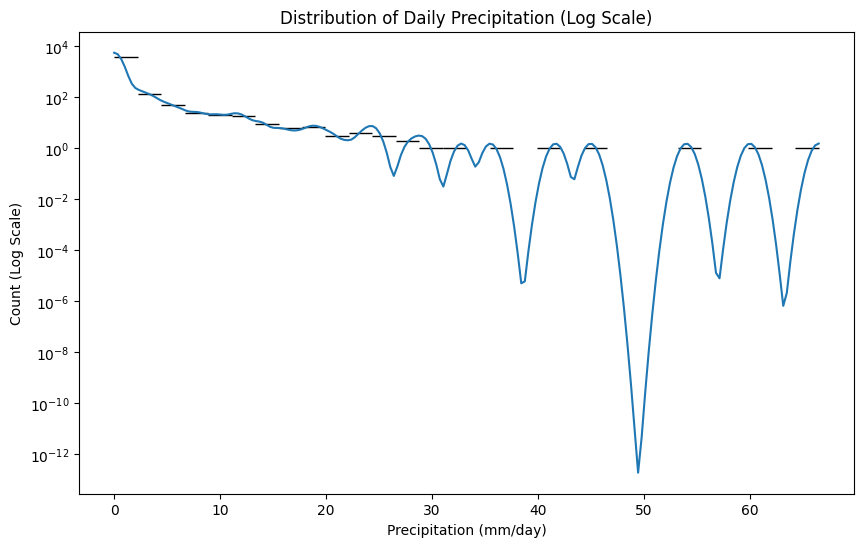

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Using a log scale because rainfall is usually heavily skewed towards zero
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, log_scale=(False, True))
plt.title('Distribution of Daily Precipitation (Log Scale)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Count (Log Scale)')
plt.show()

In [20]:
import os

# Create directory if it doesn't exist
if not os.path.exists('../data'):
    os.makedirs('../data')

# Export cleaned data
df.to_csv("../data/sudan_clean.csv", index=False)
print("Cleaned data saved to data/sudan_clean.csv")

Cleaned data saved to data/sudan_clean.csv


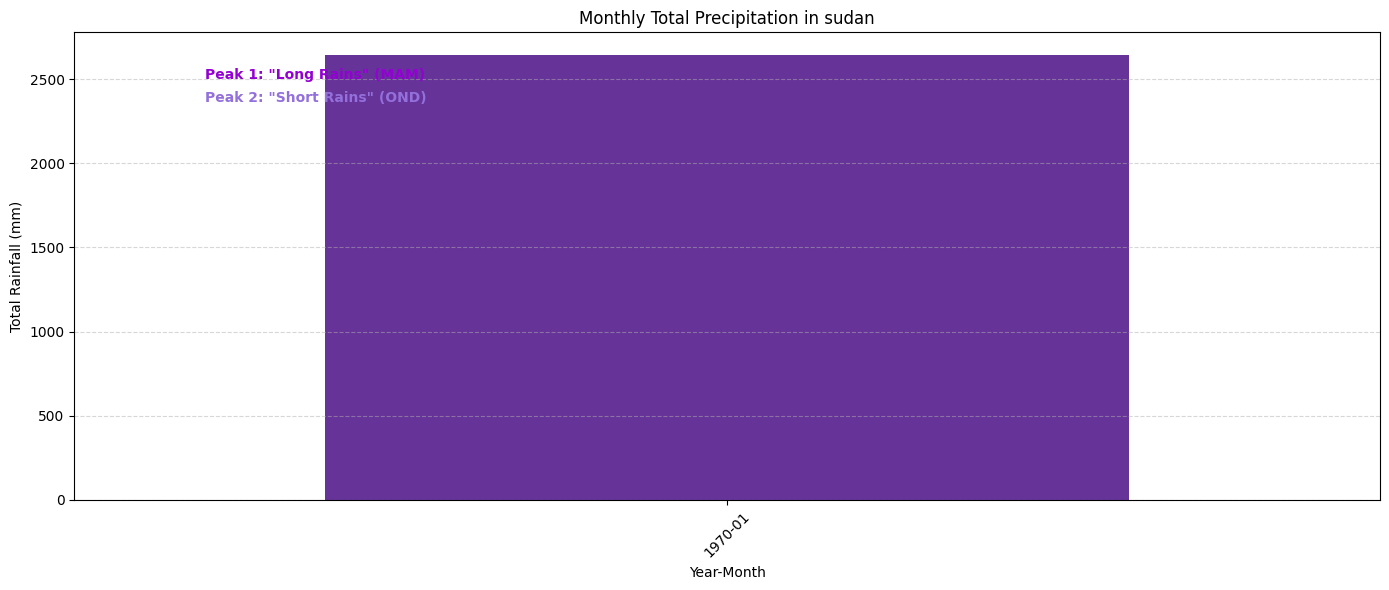

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. FIND THE DATE (Defensive Check)
# Check if Date is the index already
if df.index.name == 'Date' or isinstance(df.index, pd.DatetimeIndex):
    pass 
# If 'Date' is a column, set it
elif 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
# If it's hidden in a renamed index, fix it
else:
    df = df.reset_index()
    # Find a column that looks like dates (usually the first one)
    potential_date_col = [col for col in df.columns if 'Date' in col or 'index' in col][0]
    df.rename(columns={potential_date_col: 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# 2. Resample to Monthly End (ME)
monthly_rain = df.resample('ME')['PRECTOTCORR'].sum()

# 3. Create the Bar Chart
plt.figure(figsize=(14, 6))
monthly_rain.plot(kind='bar', color='rebeccapurple', width=0.8)

# 4. Clean up X-axis labels
n = 12 
ax = plt.gca()
ticklabels = [d.strftime('%Y-%m') for d in monthly_rain.index]
ax.set_xticks(range(0, len(ticklabels), n))
ax.set_xticklabels(ticklabels[::n], rotation=45)

# 5. Labels and Titles
plt.title('Monthly Total Precipitation in sudan')
plt.xlabel('Year-Month')
plt.ylabel('Total Rainfall (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Seasonal Labels
plt.text(0.1, 0.9, 'Peak 1: "Long Rains" (MAM)', transform=ax.transAxes, color='darkviolet', fontweight='bold')
plt.text(0.1, 0.85, 'Peak 2: "Short Rains" (OND)', transform=ax.transAxes, color='mediumpurple', fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# Save the cleaned data to your data folder
df.to_csv("../data/sudan_clean.csv")
print("Data exported successfully.")

Data exported successfully.
